In [ ]:
# objective of the study is to analyse the flight booking dataset
# conduct hypothesis tests and perform linear regression to predict price of flight

# # Research Questions:
# a) Does price vary with Airlines?
# b) How is the price affected when tickets are bought in just 1 or 2 days before departure?
# c) Does ticket price change based on the departure time and arrival time?
# d) How the price changes with change in Source and Destination?
# e) How does the ticket price vary between Economy and Business class?

In [1]:
# Load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Load dataset
df = pd.read_csv("Clean_Dataset.csv")

In [16]:
# Lets' view first 5 rows of data
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [20]:
# View structure of dataset
df.info()

# 12 variables but it really is 11 variables since Unnamed has no significant meaning
# 8 character variables and 3 numerical variables including our predictor which is price


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   airline           300153 non-null  object
 1   source_city       300153 non-null  object
 2   departure_time    300153 non-null  object
 3   stops             300153 non-null  object
 4   arrival_time      300153 non-null  object
 5   destination_city  300153 non-null  object
 6   class             300153 non-null  object
 7   days_left         300153 non-null  int64 
 8   price             300153 non-null  int64 
dtypes: int64(2), object(7)
memory usage: 20.6+ MB


In [3]:
# Drop unnamed, flight and duration columns since they are not important for this analysis  
df.drop(["Unnamed: 0", "flight", "duration"], axis=1, inplace=True)

# Now we have 9 variables in which 7 are character and 2 are numerical type

In [21]:
# Let's check to see if there are missing values in the data
df.isnull().sum().sort_values(ascending=False)

# No missing values in dataset

airline             0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
days_left           0
price               0
dtype: int64

In [7]:
# Check to see if there are any duplicate observations and if so remove them
df.duplicated().sum()       # No duplicates in data

0

In [22]:
# View summary statistics for numerical variables
df.describe()

,days_left,price
count,300153.000000,300153.000000
mean,26.004751,20889.660523
std,13.561004,22697.767366
min,1.000000,1105.000000
25%,15.000000,4783.000000
50%,26.000000,7425.000000
75%,38.000000,42521.000000
max,49.000000,123071.000000


In [23]:
# Get the value counts for character variables
df.describe(include=["object"])

,airline,source_city,departure_time,stops,arrival_time,destination_city,class
count,300153,300153,300153,300153,300153,300153,300153
unique,6,6,6,3,6,6,2
top,Vistara,Delhi,Morning,one,Night,Mumbai,Economy
freq,127859,61343,71146,250863,91538,59097,206666


In [55]:
# Let's perform Univariate Analysis for data
# Look at numerical variables first
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

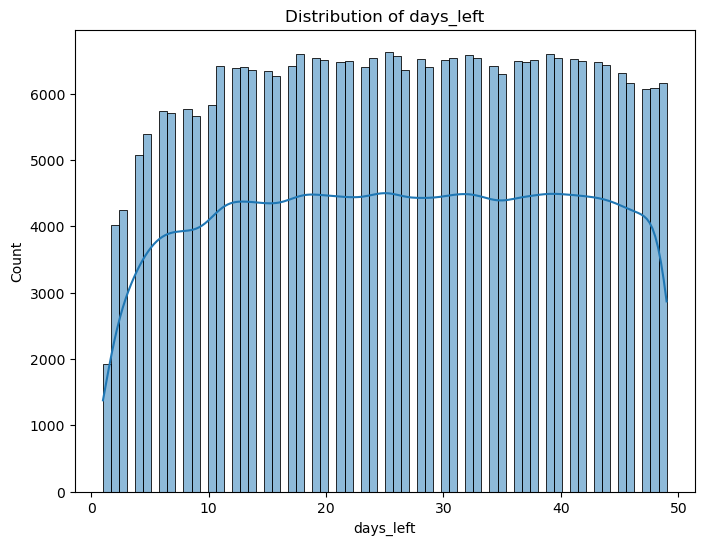

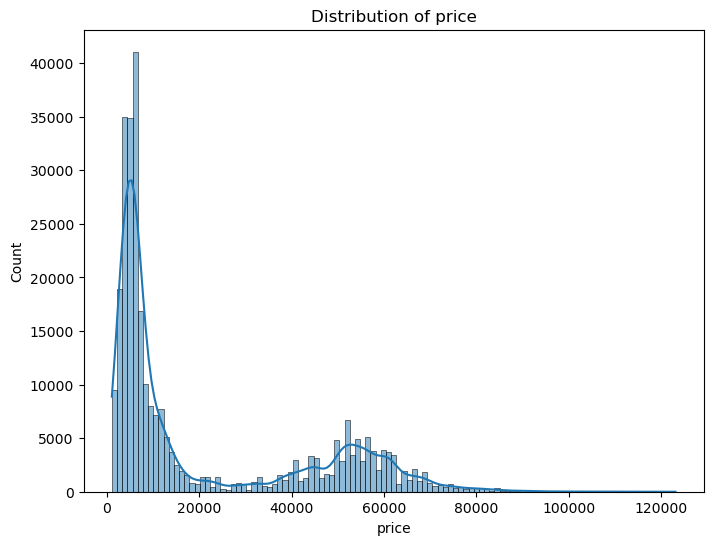

In [25]:
# View histograms
for col in num_cols:
    plt.figure(figsize=(8,6))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()



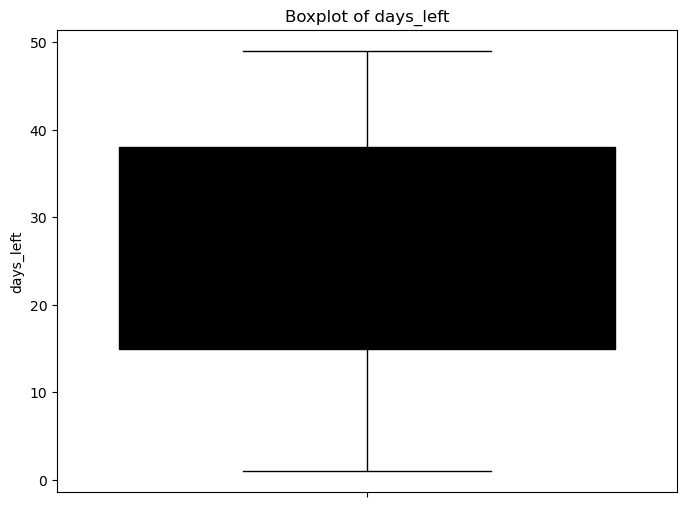

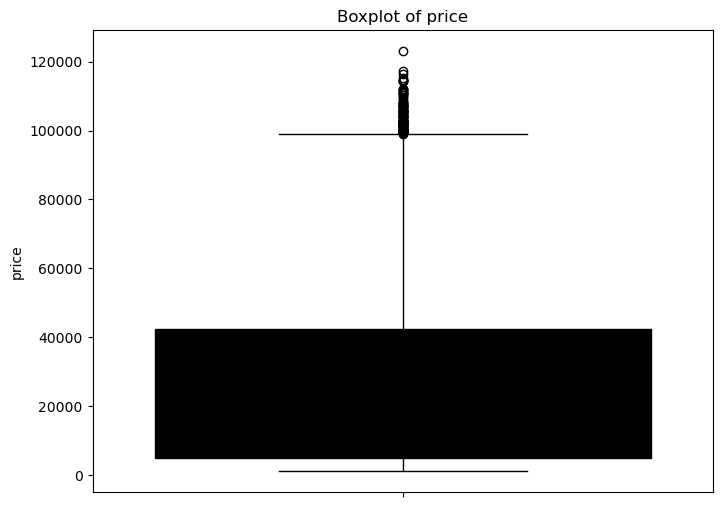

In [ ]:
# Let's look at boxplots to see if there are any outliers 
for col in num_cols:
    plt.figure(figsize=(8,6))
    sns.boxplot(y=df[col], color="black")
    plt.title(f"Boxplot of {col}")
    plt.show()

# Price has a lot of outliers above the 3rd quartile meaning that their are some expensive flights

# further analysis can be used determine which observations are actually outliers in the data

In [56]:
# Let's look at bar plots for categorical variables
cat_cols = df.select_dtypes(include=['object']).columns

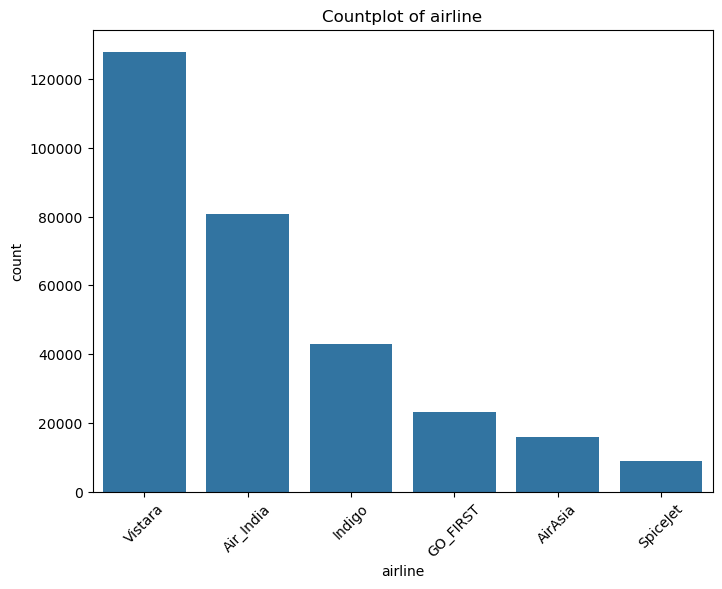

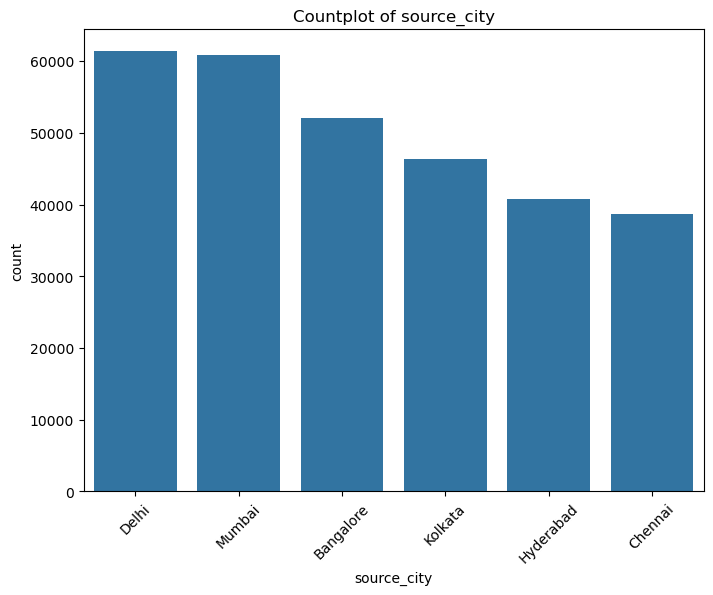

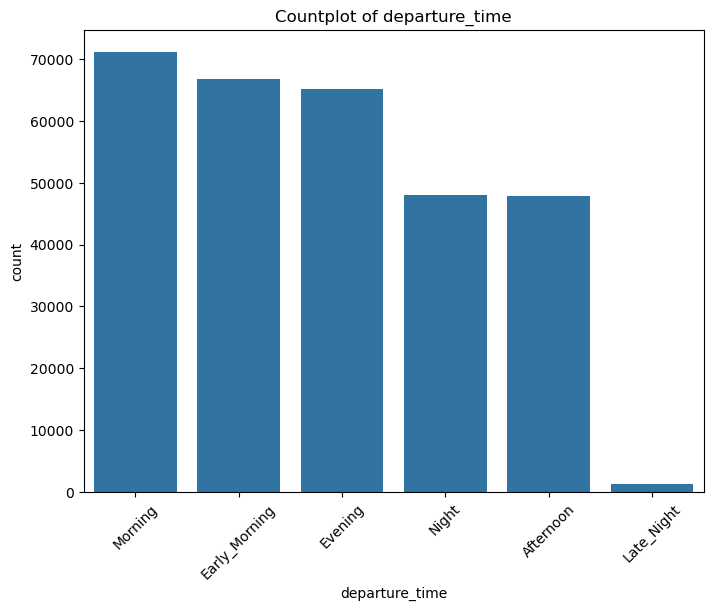

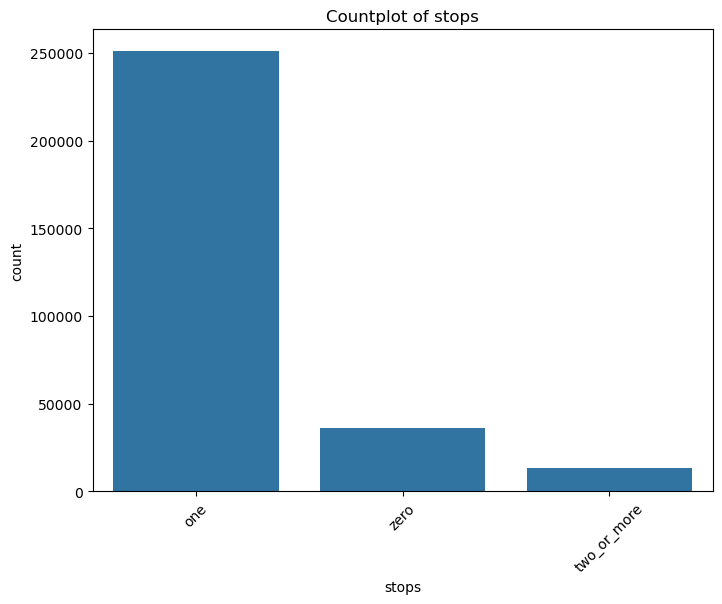

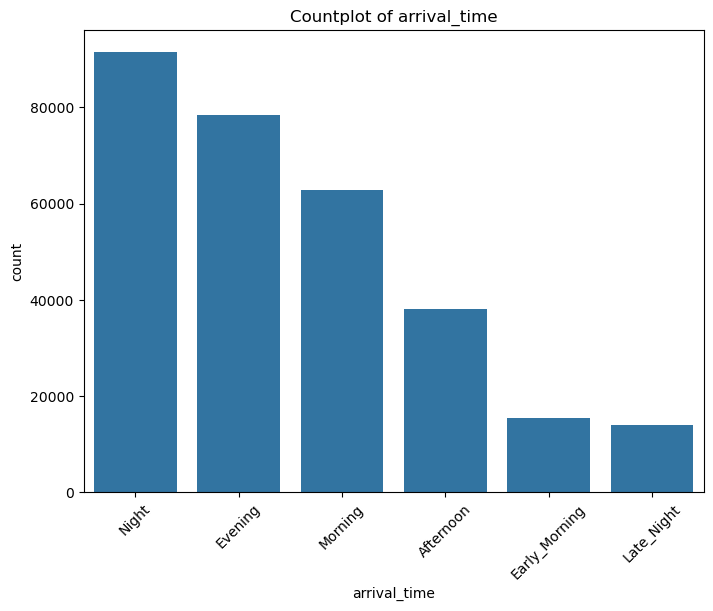

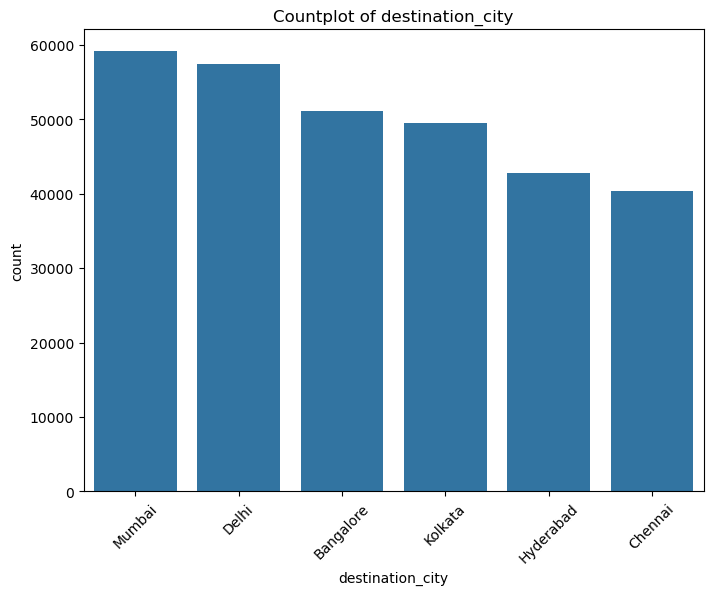

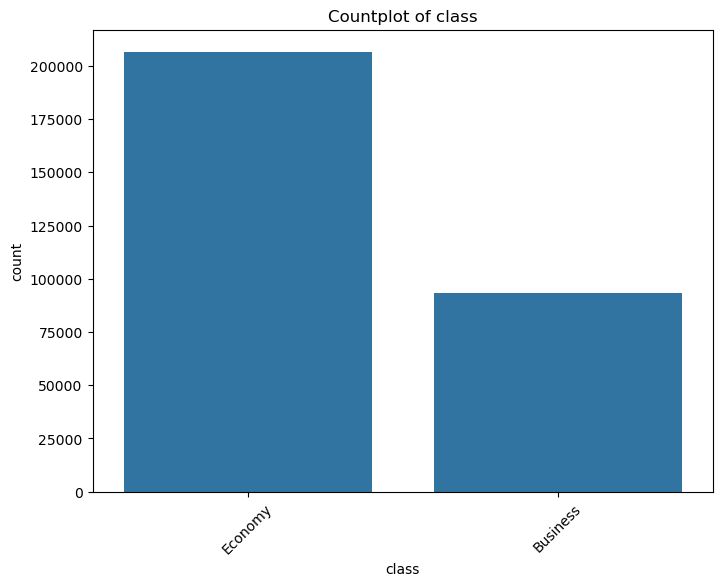

In [ ]:
for col in cat_cols:
    plt.figure(figsize=(8,6))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f"Countplot of {col}")
    plt.xticks(rotation=45)
    plt.show()
    

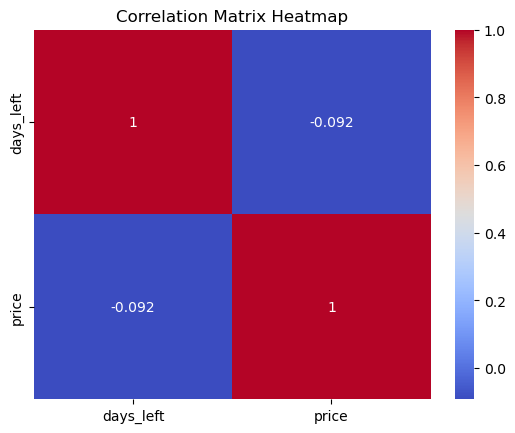

In [ ]:
# Let's look at correlation heatmaps and scatterplot matrix for numeric variables to see if there is a relationship among them
# Correlation matrix
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix Heatmap")
plt.show()

# there is no correlation between price, days_left
# days_left does not have a relationship with flight price

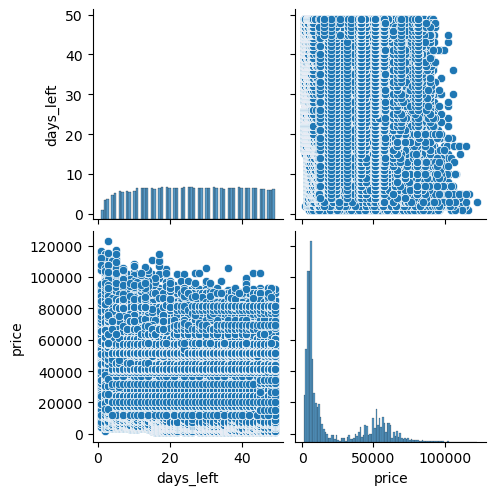

In [30]:
# Visualize scatterplot matrix
sns.pairplot(df[num_cols])
plt.show()

In [ ]:
# Let's look at first question: Do prices vary with airlines

In [11]:
# Let's group airlines by price
airline_price = df.groupby('airline')['price'].mean()   # Average airline flight price

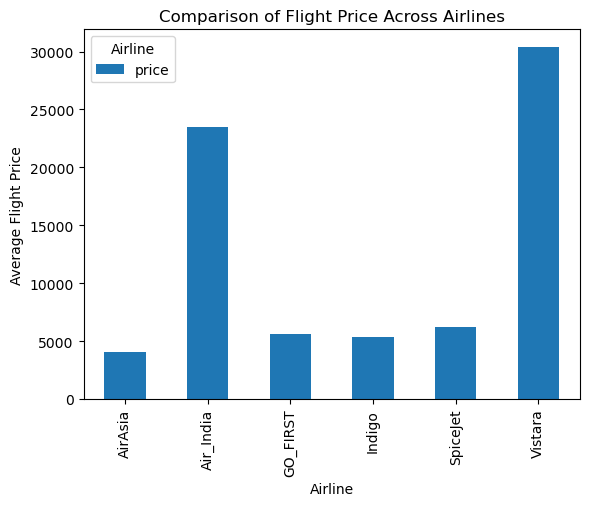

In [12]:
# Visualize
airline_price.plot(kind='bar')
plt.xlabel('Airline')
plt.ylabel('Average Flight Price')
plt.title("Comparison of Flight Price Across Airlines")
plt.legend(title="Airline")
plt.show()

# We can see that Vistara flight price is alot higher than the others. Air India also has higher prices than the other 4
# Seems that prices of airlines differ

In [4]:
# Let's use ANOVA to test and see if there is significant differences in the average flight prices for each airline
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [5]:
# Define the model: Dependent_Variable ~ C(Independent_Variable)
model = ols('price ~ C(airline)', data=df).fit()

# Perform ANOVA
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

# F-statisic is extremely large indicating that there is a significant different the flight prices between airlines
# At least one airline prices is different than the others

                  sum_sq        df             F  PR(>F)
C(airline)  3.443051e+13       5.0  17194.402096     0.0
Residual    1.202044e+14  300147.0           NaN     NaN


In [ ]:
# Use Tukey's Test to determine which airline prices differ
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey_airline = pairwise_tukeyhsd(endog=df['price'], groups=df['airline'], alpha=0.05)
print(tukey_airline)

# From the results below we see that there is a significant difference between most of the airlines except for
# GO_FIRST -> Indigo and GO_FIRST -> SpiceJet

         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
  group1    group2    meandiff  p-adj     lower       upper    reject
---------------------------------------------------------------------
  AirAsia Air_India  19415.9464    0.0  18923.7733  19908.1195   True
  AirAsia  GO_FIRST   1560.9349    0.0    975.8053   2146.0644   True
  AirAsia    Indigo   1233.1436    0.0    706.4055   1759.8816   True
  AirAsia  SpiceJet   2088.2061    0.0   1337.9054   2838.5069   True
  AirAsia   Vistara  26305.4636    0.0    25828.53  26782.3972   True
Air_India  GO_FIRST -17855.0115    0.0  -18279.926  -17430.097   True
Air_India    Indigo -18182.8028    0.0  -18522.845 -17842.7606   True
Air_India  SpiceJet -17327.7402    0.0 -17961.0861 -16694.3944   True
Air_India   Vistara   6889.5172    0.0   6633.3114    7145.723   True
 GO_FIRST    Indigo   -327.7913 0.3359   -792.3028    136.7202  False
 GO_FIRST  SpiceJet    527.2713 0.2756   -180.7324    1235.275  False
 GO_FIRST   Vistara 

In [ ]:
# Second question
# b) How is the price affected when tickets are bought in just 1 or 2 days before departure?


c:\Users\shirl\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


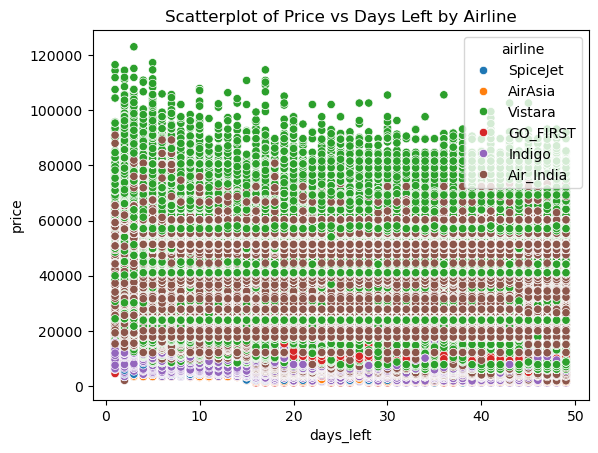

In [31]:
sns.scatterplot(
    data=df,
    x="days_left",
    y="price",
    hue="airline"
)

plt.title("Scatterplot of Price vs Days Left by Airline")
plt.show()

In [ ]:
# Does ticket price change based on the departure time and arrival time?


In [34]:
# Let's groupby departure time and then groupby arrival time
departure_price = df.groupby('departure_time')['price'].mean()
arrival_price = df.groupby('arrival_time')['price'].mean()

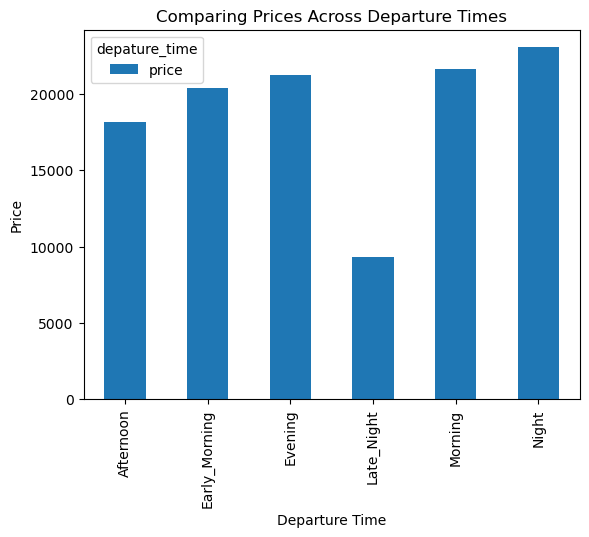

In [35]:
departure_price.plot(kind="bar")
plt.xlabel('Departure Time')
plt.ylabel("Price")
plt.title("Comparing Prices Across Departure Times")
plt.legend(title="depature_time")
plt.show()

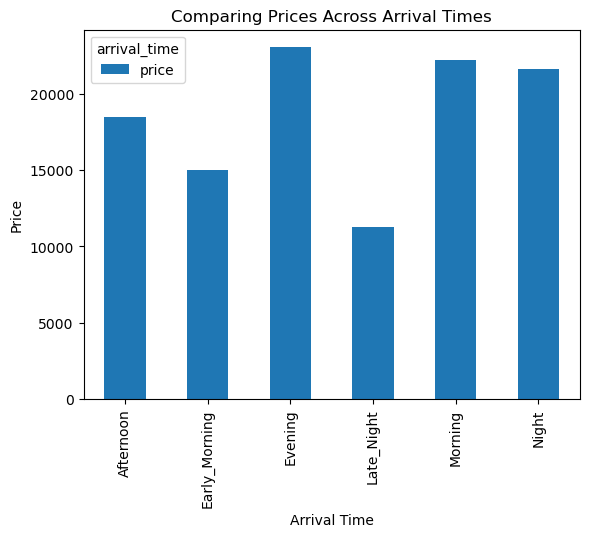

In [36]:
arrival_price.plot(kind="bar")
plt.xlabel("Arrival Time")
plt.ylabel("Price")
plt.title("Comparing Prices Across Arrival Times")
plt.legend(title="arrival_time")
plt.show()

In [ ]:
# Perform ANOVA to see if there is a significant difference in the departure times and arrival times
# Define the model:
model = ols('price ~ C(departure_time)', data=df).fit()

# Perform ANOVA
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

# There is a significant difference in the prices in the departure times
# The price for either departure or arrival times are different from each other

# Perform Tukey's HSD to see which departure times prices are different from each other
tukey_depart = pairwise_tukeyhsd(endog=df['price'], groups=df['departure_time'], alpha=0.05)
print(tukey_depart)

                         sum_sq        df           F  PR(>F)
C(departure_time)  8.180139e+11       5.0  319.242483     0.0
Residual           1.538169e+14  300147.0         NaN     NaN


In [ ]:
# Perform Tukey's HSD to see which departure times prices are different from each other
tukey_depart = pairwise_tukeyhsd(endog=df['price'], groups=df['departure_time'], alpha=0.05)
print(tukey_depart)

# All departure times prices are significantly different from each other

             Multiple Comparison of Means - Tukey HSD, FWER=0.05             
    group1        group2      meandiff  p-adj     lower       upper    reject
-----------------------------------------------------------------------------
    Afternoon Early_Morning   2191.4734    0.0   1804.9689   2577.9779   True
    Afternoon       Evening   3053.1586    0.0   2664.5697   3441.7475   True
    Afternoon    Late_Night  -8883.9039    0.0 -10693.2325  -7074.5754   True
    Afternoon       Morning   3451.5569    0.0   3070.0196   3833.0942   True
    Afternoon         Night   4882.9435    0.0   4466.1096   5299.7773   True
Early_Morning       Evening    861.6852    0.0    506.3884    1216.982   True
Early_Morning    Late_Night -11075.3773    0.0 -12877.8491  -9272.9056   True
Early_Morning       Morning   1260.0835    0.0    912.5131    1607.654   True
Early_Morning         Night   2691.4701    0.0   2305.4844   3077.4558   True
      Evening    Late_Night -11937.0625    0.0 -13739.9824 -1013

In [ ]:
# Define the model: 
model = ols('price ~ C(arrival_time)', data=df).fit()

# Perform ANOVA
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

# There is a significant difference in the prices for different arrival times
# Some arrival times prices are either more or less than other arrival times

                       sum_sq        df           F  PR(>F)
C(arrival_time)  2.567425e+12       5.0  1013.50396     0.0
Residual         1.520675e+14  300147.0         NaN     NaN


In [ ]:
# Perform Tukey's HSD to see which arrival times prices are different from each other
tukey_arrival = pairwise_tukeyhsd(endog=df['price'], groups=df['arrival_time'], alpha=0.05)
print(tukey_arrival)

# All arrival times have significantly different prices from one another

            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
    group1        group2      meandiff  p-adj    lower       upper    reject
----------------------------------------------------------------------------
    Afternoon Early_Morning  -3501.4595   0.0  -4113.6275  -2889.2915   True
    Afternoon       Evening   4549.7726   0.0   4149.2621   4950.2832   True
    Afternoon    Late_Night  -7209.6929   0.0  -7843.5224  -6575.8634   True
    Afternoon       Morning   3736.4771   0.0   3319.9904   4152.9638   True
    Afternoon         Night   3092.1593   0.0   2701.2309   3483.0878   True
Early_Morning       Evening   8051.2321   0.0   7486.0752    8616.389   True
Early_Morning    Late_Night  -3708.2334   0.0  -4457.0548  -2959.4121   True
Early_Morning       Morning   7237.9366   0.0   6661.3477   7814.5255   True
Early_Morning         Night   6593.6188   0.0   6035.2116   7152.0261   True
      Evening    Late_Night -11759.4655   0.0 -12348.0167 -11170.9143   True

In [ ]:
# How the price changes with change in Source and Destination?


In [40]:
# Groupby source city and destination city by price
source_price = df.groupby('source_city')['price'].mean()
destination_price = df.groupby('destination_city')['price'].mean()

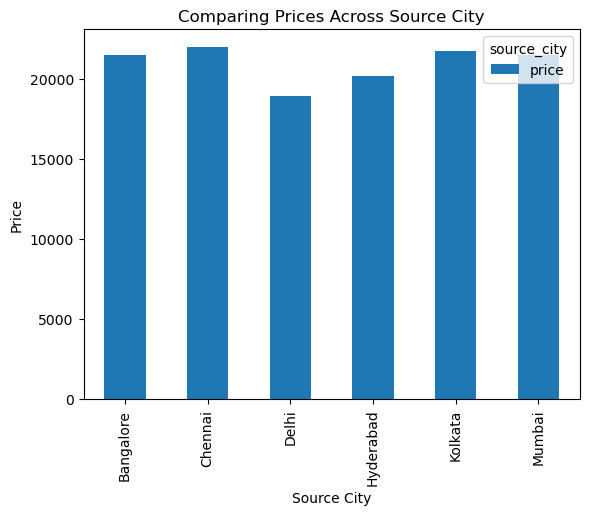

In [41]:
source_price.plot(kind="bar")
plt.xlabel("Source City")
plt.ylabel("Price")
plt.title("Comparing Prices Across Source City")
plt.legend(title="source_city")
plt.show()

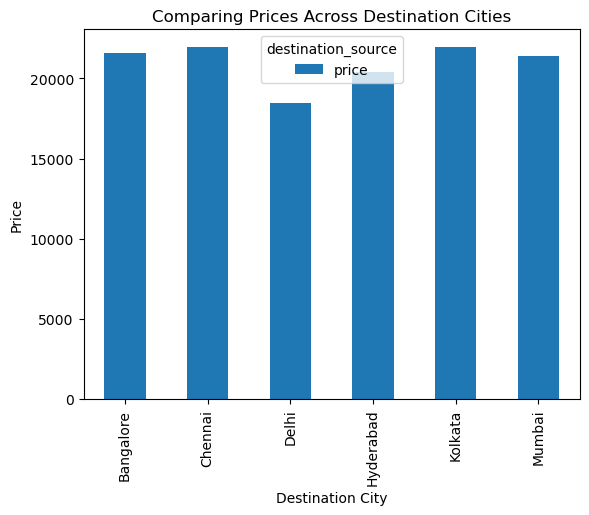

In [42]:
destination_price.plot(kind="bar")
plt.xlabel("Destination City")
plt.ylabel("Price")
plt.title("Comparing Prices Across Destination Cities")
plt.legend(title="destination_source")
plt.show()

In [ ]:
# Define the model: 
model = ols('price ~ C(source_city)', data=df).fit()

# Perform ANOVA
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

# There is a significant difference in the flight prices across different source cities

                      sum_sq        df           F         PR(>F)
C(source_city)  3.727774e+11       5.0  145.062189  2.550099e-154
Residual        1.542621e+14  300147.0         NaN            NaN


In [10]:
# Perform Tukey's HSD to see which source cities prices are different from each other
tukey_source = pairwise_tukeyhsd(endog=df['price'], groups=df['source_city'], alpha=0.05)
print(tukey_source)

       Multiple Comparison of Means - Tukey HSD, FWER=0.05        
  group1    group2   meandiff  p-adj    lower      upper    reject
------------------------------------------------------------------
Bangalore   Chennai   525.8793 0.0072    92.2681   959.4905   True
Bangalore     Delhi -2518.1339    0.0 -2903.1138  -2133.154   True
Bangalore Hyderabad -1313.8367    0.0 -1740.9814   -886.692   True
Bangalore   Kolkata   276.7751 0.3948  -135.8074   689.3576  False
Bangalore    Mumbai    14.3583    1.0  -371.2697   399.9863  False
  Chennai     Delhi -3044.0132    0.0 -3463.4031 -2624.6233   True
  Chennai Hyderabad  -1839.716    0.0 -2298.1165 -1381.3155   True
  Chennai   Kolkata  -249.1042 0.6014  -693.9667   195.7583  False
  Chennai    Mumbai   -511.521 0.0069   -931.506   -91.5361   True
    Delhi Hyderabad  1204.2972    0.0   791.5966  1616.9979   True
    Delhi   Kolkata   2794.909    0.0  2397.2993  3192.5188   True
    Delhi    Mumbai  2532.4922    0.0  2162.9274   2902.057   

In [ ]:
# Define the model: 
model = ols('price ~ C(destination_city)', data=df).fit()

# Perform ANOVA
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

# There is a significant difference in flight prices across different destination cities

                           sum_sq        df           F         PR(>F)
C(destination_city)  4.957191e+11       5.0  193.057482  4.245267e-206
Residual             1.541392e+14  300147.0         NaN            NaN


In [11]:
# Perform Tukey's HSD to see which destination city prices are different from each other
tukey_desti = pairwise_tukeyhsd(endog=df['price'], groups=df['destination_city'], alpha=0.05)
print(tukey_desti)

       Multiple Comparison of Means - Tukey HSD, FWER=0.05        
  group1    group2   meandiff  p-adj    lower      upper    reject
------------------------------------------------------------------
Bangalore   Chennai   359.3682 0.1628   -70.7176   789.4539  False
Bangalore     Delhi -3157.1879    0.0 -3550.0872 -2764.2886   True
Bangalore Hyderabad -1166.2945    0.0    -1589.7   -742.889   True
Bangalore   Kolkata   365.6018 0.1078   -41.6535    772.857  False
Bangalore    Mumbai  -221.4263  0.587  -611.5966   168.7439  False
  Chennai     Delhi -3516.5561    0.0 -3936.0985 -3097.0137   True
  Chennai Hyderabad -1525.6627    0.0 -1973.9016 -1077.4237   True
  Chennai   Kolkata     6.2336    1.0  -426.7823   439.2495  False
  Chennai    Mumbai  -580.7945  0.001  -997.7823  -163.8067   True
    Delhi Hyderabad  1990.8934    0.0   1578.202  2403.5849   True
    Delhi   Kolkata  3522.7897    0.0  3126.6851  3918.8943   True
    Delhi    Mumbai  2935.7616    0.0  2557.2449  3314.2783   

In [47]:
# How does the ticket price vary between Economy and Business class?
# Group class by price
class_price = df.groupby('class')['price'].mean().sort_values()

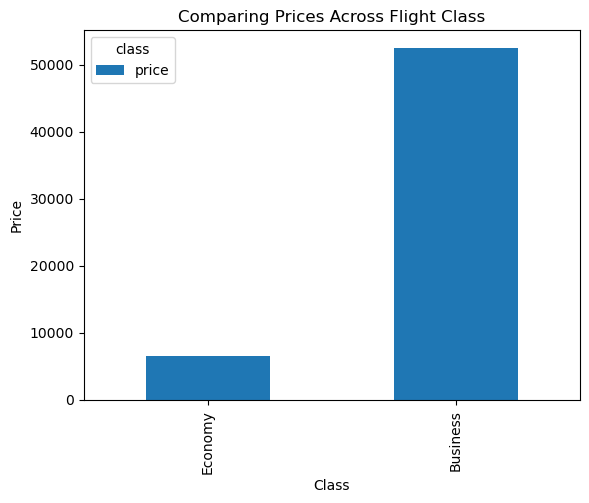

In [ ]:
class_price.plot(kind="bar")
plt.xlabel("Class")
plt.ylabel("Price")
plt.title("Comparing Prices Across Flight Class")
plt.legend(title="class")
plt.show()

# Ticket prices for Business class are a lot more expensive than ticket for economy class

In [57]:
# Now we can build a model to predict flight price
# Let's encode categorical variables
df = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)

In [59]:
# Select features and target variable
X = df.drop('price', axis=1)
y = df['price']

In [60]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [61]:
# Fit model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [62]:
# Make predictions
y_pred_train = lr_model.predict(X_train)
y_pred_test  = lr_model.predict(X_test)

In [63]:
# Evalute Model Performance
mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)

mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print("\nModel Performance:")
print(f"Training MSE: {mse_train:.2f}, R2: {r2_train:.2f}")
print(f"Testing MSE: {mse_test:.2f}, R2: {r2_test:.2f}")


Model Performance:
Training MSE: 45696373.97, R2: 0.91
Testing MSE: 45602499.01, R2: 0.91


In [ ]:
# Coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
})
print("\nLinear Regression Coefficients:\n", coef_df)
print("Intercept:", lr_model.intercept_)

# Extremely large coefficients(maybe scaling can be useful instead of inputing unscaled data)


Linear Regression Coefficients:
                          Feature   Coefficient
0                      days_left   -131.304281
1              airline_Air_India    355.992561
2               airline_GO_FIRST   1686.080588
3                 airline_Indigo   2039.338099
4               airline_SpiceJet   2496.162362
5                airline_Vistara   4237.802444
6            source_city_Chennai    -50.592194
7              source_city_Delhi  -1440.714353
8          source_city_Hyderabad  -1648.736430
9            source_city_Kolkata   1649.045108
10            source_city_Mumbai   -230.271842
11  departure_time_Early_Morning    807.961894
12        departure_time_Evening    859.981840
13     departure_time_Late_Night   1592.284405
14        departure_time_Morning    864.809935
15          departure_time_Night    756.623471
16             stops_two_or_more   2165.893585
17                    stops_zero  -8055.106991
18    arrival_time_Early_Morning   -729.798268
19          arrival_time_E

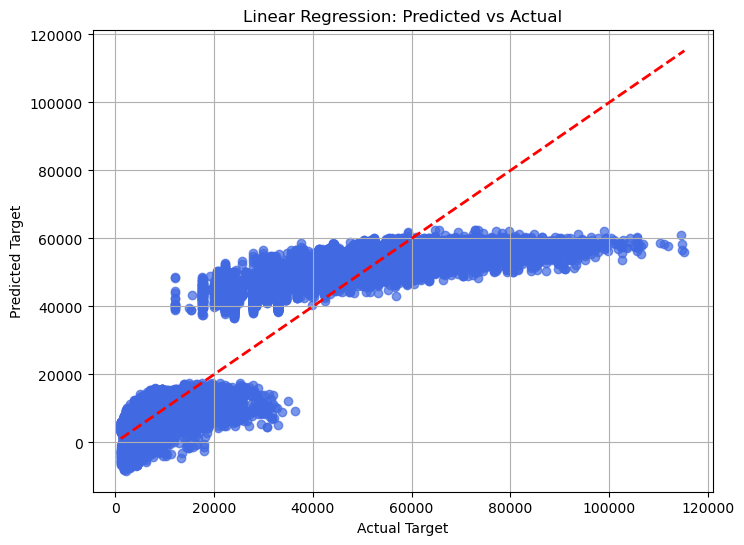

In [66]:
# Visualizing
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_test, alpha=0.7, color='royalblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Target")
plt.ylabel("Predicted Target")
plt.title("Linear Regression: Predicted vs Actual")
plt.grid(True)
plt.show()